# Top 5 media conditions vs `ctrl_media` @ 590 nm

Biolog PM08 SN1 series. Ranks conditions by mean AUC of Δabs₅₉₀ across replicate wells (pooled across plates), then plots the top 5 winners with the control overlaid (mean ± std band).

Inputs:
- `outputs/growth_long.csv` — tidy per-well kinetics (produced by `plot_growth.py`).
- `well_assignment.xlsx` — well → condition/replicate mapping.

Outputs (this folder):
- `outputs/conditions/top5_vs_control_590_nb.png`
- `outputs/conditions/top5_vs_control_590_nb.pdf`

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/snaseem/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/snaseem/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
HERE = Path.cwd()
GROWTH_CSV = HERE / 'outputs' / 'growth_long.csv'
ASSIGN_XLSX = HERE / 'well_assignment.xlsx'
OUT_DIR = HERE / 'outputs' / 'conditions'
OUT_DIR.mkdir(parents=True, exist_ok=True)

WAVELENGTH = 590
TOP_N = 5
CONTROL = 'ctrl_media'
PLATE_MAP = {1: 'SN1_1c', 2: 'SN1_2c', 3: 'SN1_3c', 4: 'SN1_4c'}
EXCLUDE_PREFIXES = ('Nd',)  # drop calibrant wells

In [5]:
growth = pd.read_csv(GROWTH_CSV)
growth = growth[growth['wavelength'] == WAVELENGTH].copy()
print(f'{len(growth):,} rows @ {WAVELENGTH} nm across {growth["plate"].nunique()} plates')
growth.head()

55,296 rows @ 590 nm across 4 plates


,plate_uuid,well,row,col,wavelength,t_h,abs,plate
0,5683f0c2-896e-414c-9a11-15a929454386,A01,A,1,590,0.000000,0.144916,SN1_1c
1,5683f0c2-896e-414c-9a11-15a929454386,A01,A,1,590,0.333333,0.147001,SN1_1c
2,5683f0c2-896e-414c-9a11-15a929454386,A01,A,1,590,0.665833,0.149734,SN1_1c
3,5683f0c2-896e-414c-9a11-15a929454386,A01,A,1,590,1.000000,0.153580,SN1_1c
4,5683f0c2-896e-414c-9a11-15a929454386,A01,A,1,590,1.333333,0.156043,SN1_1c


In [6]:
def normalize_well(w: str) -> str:
    w = str(w).strip()
    return f'{w[0].upper()}{int(w[1:]):02d}'

assign = pd.read_excel(ASSIGN_XLSX)
assign['well'] = assign['Well'].map(normalize_well)
assign['plate'] = assign['Plate'].map(PLATE_MAP)
assign = assign.dropna(subset=['plate']).rename(
    columns={'Condition_ID': 'condition', 'Replicate': 'rep'}
)
assign = assign[~assign['condition'].str.startswith(EXCLUDE_PREFIXES)]
assign = assign[['plate', 'well', 'condition', 'rep']]
print(f'{assign["condition"].nunique()} conditions across {len(assign)} wells')
assign.head()

70 conditions across 292 wells


,plate,well,condition,rep
0,SN1_1c,H11,MPOB_005,1
1,SN1_1c,G02,MPOB_005,2
2,SN1_1c,H01,MPOB_005,3
3,SN1_1c,A08,MPOB_005,4
4,SN1_1c,E11,MPOB_008,1


In [7]:
df = growth.merge(assign, on=['plate', 'well'], how='inner')
df['abs_delta'] = df['abs'] - df.groupby(['plate', 'well'])['abs'].transform('first')
df['t_bin'] = (df['t_h'] * 10).round() / 10  # 0.1-h bin for aligning across plates
print(f'{len(df):,} joined rows, {df["condition"].nunique()} conditions')

42,048 joined rows, 70 conditions


In [8]:
# Per-well AUC of Δabs over time (trapezoidal, in abs*hours).
def auc_per_well(g):
    g = g.sort_values('t_h')
    # np.trapz for NumPy < 2.0; np.trapezoid is NumPy 2.0+
    trapz = getattr(np, 'trapezoid', np.trapz)
    return trapz(g['abs_delta'].to_numpy(), g['t_h'].to_numpy())

well_auc = (df.groupby(['plate', 'well', 'condition'], as_index=False)
              .apply(lambda g: pd.Series({'AUC': auc_per_well(g)}), include_groups=False)
              .reset_index(drop=True))

cond_auc = (well_auc.groupby('condition')['AUC']
                     .agg(['mean', 'std', 'count'])
                     .reset_index()
                     .sort_values('mean', ascending=False))

top5 = (cond_auc[cond_auc['condition'] != CONTROL]
        .head(TOP_N)['condition'].tolist())

ctrl_row = cond_auc[cond_auc['condition'] == CONTROL].iloc[0]
print(f'Top {TOP_N} by mean AUC_{WAVELENGTH}:')
print(cond_auc[cond_auc['condition'].isin(top5 + [CONTROL])]
      .round(3).to_string(index=False))

Top 5 by mean AUC_590:
 condition  mean   std  count
  MPOB_008 7.066 0.252      4
  MPOB_058 6.948 0.294      4
  MPOB_041 5.748 0.255      4
  MPOB_045 5.620 0.241      4
  MPOB_068 5.403 0.144      4
ctrl_media 3.868 0.316     16


In [9]:
selected = top5 + [CONTROL]
sub = df[df['condition'].isin(selected)]
curves = (sub.groupby(['condition', 't_bin'])['abs_delta']
              .agg(['mean', 'std', 'count'])
              .reset_index())
curves['std'] = curves['std'].fillna(0.0)
print(curves.groupby('condition')['count'].max().rename('n_reps'))

condition
MPOB_008       4
MPOB_041       4
MPOB_045       4
MPOB_058       4
MPOB_068       4
ctrl_media    16
Name: n_reps, dtype: int64


wrote top5_vs_control_590_nb.png and top5_vs_control_590_nb.pdf


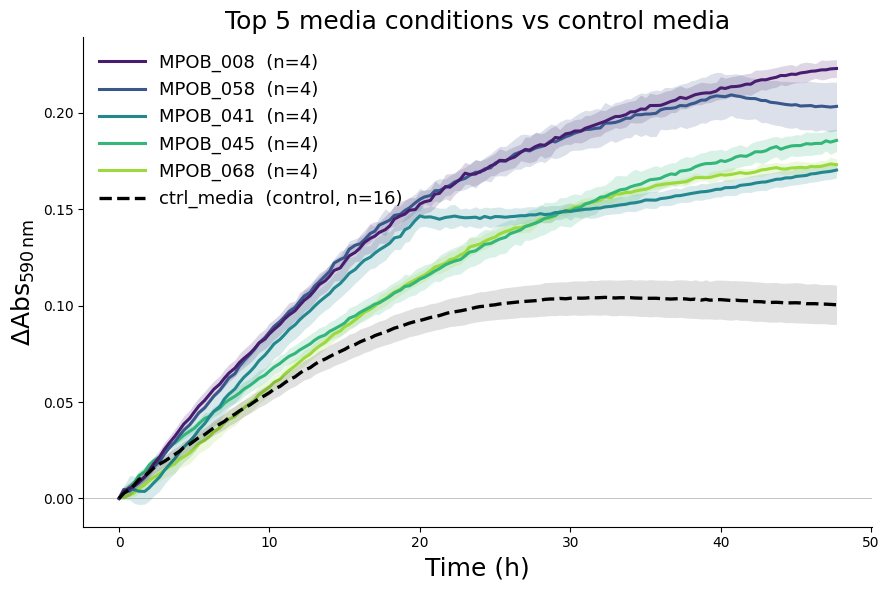

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.colormaps['viridis'](np.linspace(0.08, 0.85, TOP_N))

for i, cond in enumerate(top5):
    c = curves[curves['condition'] == cond].sort_values('t_bin')
    n = int(c['count'].max())
    ax.plot(c['t_bin'], c['mean'], color=cmap[i], lw=2.2,
            label=f'{cond}  (n={n})', zorder=5 - 0.01 * i)
    ax.fill_between(c['t_bin'], c['mean'] - c['std'], c['mean'] + c['std'],
                    color=cmap[i], alpha=0.18, lw=0)

ctrl = curves[curves['condition'] == CONTROL].sort_values('t_bin')
n_ctrl = int(ctrl['count'].max())
ax.plot(ctrl['t_bin'], ctrl['mean'], color='black', lw=2.4, ls='--',
        label=f'{CONTROL}  (control, n={n_ctrl})', zorder=10)
ax.fill_between(ctrl['t_bin'], ctrl['mean'] - ctrl['std'], ctrl['mean'] + ctrl['std'],
                color='black', alpha=0.12, lw=0, zorder=9)

ax.set_xlabel('Time (h)', fontsize=18)
ax.set_ylabel(rf'$\Delta$Abs$_{{{WAVELENGTH}\,\mathrm{{nm}}}}$',
              fontsize=18)
ax.set_title(f'Top {TOP_N} media conditions vs control media',
             fontsize=18)
ax.legend(loc='upper left', fontsize=13, frameon=False, handlelength=2.5)
ax.axhline(0, color='black', lw=0.4, alpha=0.4)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.tick_params(labelsize=10)
fig.tight_layout()

out_png = OUT_DIR / f'top5_vs_control_{WAVELENGTH}_nb.png'
out_pdf = OUT_DIR / f'top5_vs_control_{WAVELENGTH}_nb.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print(f'wrote {out_png.name} and {out_pdf.name}')
plt.show()

wrote MPOB_019_vs_control_590_nb.png and MPOB_019_vs_control_590_nb.pdf  (plate(s): SN1_1c)


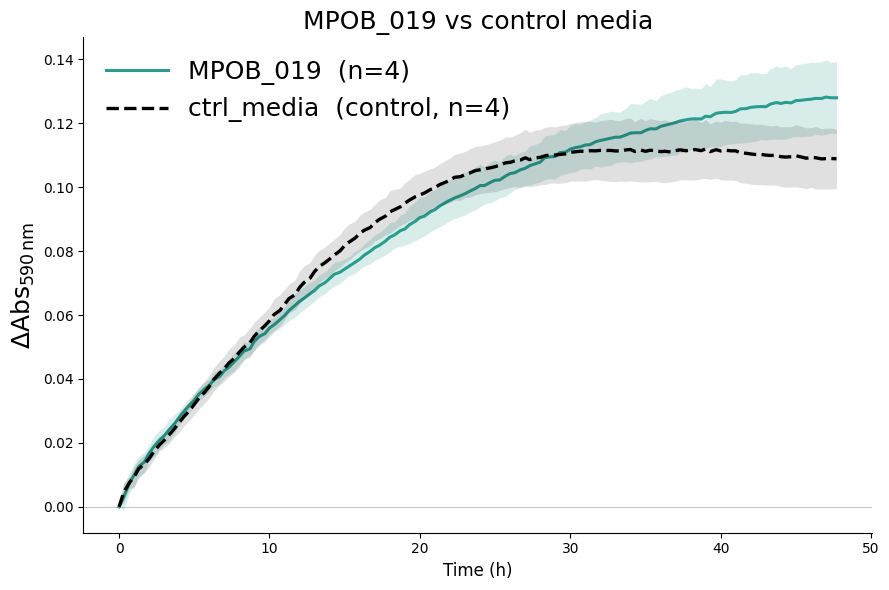

In [11]:
# MPOB_019 vs plate-matched ctrl_media (same plate only).
FOCUS = 'MPOB_019'
focus_plates = sorted(df.loc[df['condition'] == FOCUS, 'plate'].unique())
pair = df[(df['plate'].isin(focus_plates))
          & (df['condition'].isin([FOCUS, CONTROL]))].copy()

pair_curves = (pair.groupby(['condition', 't_bin'])['abs_delta']
                    .agg(['mean', 'std', 'count'])
                    .reset_index())
pair_curves['std'] = pair_curves['std'].fillna(0.0)

fig, ax = plt.subplots(figsize=(9, 6))
cond_style = {
    FOCUS:   dict(color='#2a9d8f', lw=2.2, ls='-',  zorder=5),
    CONTROL: dict(color='black',   lw=2.4, ls='--', zorder=10),
}
fill_alpha = {FOCUS: 0.18, CONTROL: 0.12}

for cond in (FOCUS, CONTROL):
    c = pair_curves[pair_curves['condition'] == cond].sort_values('t_bin')
    n = int(c['count'].max())
    st = cond_style[cond]
    label = f'{cond}  (n={n})' if cond != CONTROL else f'{CONTROL}  (control, n={n})'
    ax.plot(c['t_bin'], c['mean'], label=label, **st)
    ax.fill_between(c['t_bin'], c['mean'] - c['std'], c['mean'] + c['std'],
                    color=st['color'], alpha=fill_alpha[cond], lw=0,
                    zorder=st['zorder'] - 1)

plates_label = ', '.join(focus_plates)
ax.set_xlabel('Time (h)', fontsize=12)
ax.set_ylabel(rf'$\Delta$Abs$_{{{WAVELENGTH}\,\mathrm{{nm}}}}$',
              fontsize=18)
ax.set_title(f'{FOCUS} vs control media', fontsize=18)
ax.legend(loc='upper left', fontsize=18, frameon=False, handlelength=2.5)
ax.axhline(0, color='black', lw=0.4, alpha=0.4)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.tick_params(labelsize=10)
fig.tight_layout()

out_png = OUT_DIR / f'{FOCUS}_vs_control_{WAVELENGTH}_nb.png'
out_pdf = OUT_DIR / f'{FOCUS}_vs_control_{WAVELENGTH}_nb.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print(f'wrote {out_png.name} and {out_pdf.name}  (plate(s): {plates_label})')
plt.show()


## Specific growth rate µ_max @ 590 nm

Per-well routine (same as `analyze_conditions.py`, applied here to Δabs₅₉₀):

1. Sort by time, baseline-subtract each well against its own t=0 → `Δabs(t)`.
2. **Savitzky–Golay smooth** (window=7, poly=2) to suppress reader noise.
3. Slide a **4-h window** across the trace; in each window, linear-regress `ln(Δabs_smoothed)` on `t`.
4. **Reject** the window unless:
   - every point has `Δabs ≥ 0.015` (well above the noise floor — this restricts the fit to real exponential phase),
   - ≥ 6 points in the window,
   - R² ≥ 0.95 (truly log-linear).
5. **µ_max** = maximum accepted slope. Doubling time `t_d = ln(2) / µ_max`.

Then aggregate replicates → condition mean ± std, and compute % lift vs plate-matched control.

In [13]:
from scipy.signal import savgol_filter


def calculate_mu_max(t: np.ndarray, y: np.ndarray,
                     win_h: float = 4.0,
                     min_r2: float = 0.95,
                     min_delta_for_fit: float = 0.015,
                     min_window_points: int = 6,
                     smooth_window: int = 7,
                     smooth_polyorder: int = 2,
                     epsilon: float = 1e-4) -> float:
    """µ_max (h^-1) via sliding-window log-linear regression on baseline-subtracted,
    Savitzky–Golay-smoothed absorbance. Returns np.nan if no window passes the gates."""
    order = np.argsort(t)
    t = np.asarray(t, dtype=float)[order]
    y = np.asarray(y, dtype=float)[order]
    if len(t) < max(smooth_window, 4):
        return np.nan

    dy = y - y[0]                                            # baseline-subtracted Δabs
    win = min(smooth_window, len(dy) - (1 - len(dy) % 2))    # ensure odd & ≤ N
    if win < smooth_polyorder + 2:
        dy_smooth = dy
    else:
        if win % 2 == 0:
            win -= 1
        dy_smooth = savgol_filter(dy, win, smooth_polyorder)

    if dy_smooth.max() < min_delta_for_fit:                  # never grew
        return np.nan

    log_y = np.log(np.clip(dy_smooth, epsilon, None))

    best_slope = -np.inf
    for i in range(len(t)):
        mask = (t >= t[i]) & (t <= t[i] + win_h)
        if mask.sum() < min_window_points:
            continue
        if dy_smooth[mask].min() < min_delta_for_fit:        # any point below floor → reject
            continue
        tt = t[mask]
        yy = log_y[mask]
        slope, intercept = np.polyfit(tt, yy, 1)
        y_fit = slope * tt + intercept
        ss_res = float(((yy - y_fit) ** 2).sum())
        ss_tot = float(((yy - yy.mean()) ** 2).sum())
        if ss_tot < 1e-12:
            continue
        r2 = 1.0 - ss_res / ss_tot
        if r2 < min_r2 or slope <= 0:
            continue
        if slope > best_slope:
            best_slope = float(slope)

    return best_slope if np.isfinite(best_slope) else np.nan


# Per-well µ_max @ 590 nm (use raw abs, not baseline-subtracted — the routine subtracts internally)
mu_rows = []
for (plate, well, cond), g in df.groupby(['plate', 'well', 'condition']):
    g = g.sort_values('t_h')
    mu = calculate_mu_max(g['t_h'].to_numpy(), g['abs'].to_numpy())
    mu_rows.append({'plate': plate, 'well': well, 'condition': cond, 'mu_max': mu})
well_mu = pd.DataFrame(mu_rows)

cond_mu = (well_mu.groupby('condition')['mu_max']
                   .agg(['mean', 'std', 'count'])
                   .reset_index()
                   .sort_values('mean', ascending=False))
print(f'µ_max @ {WAVELENGTH} nm — top 5 (by AUC) + control:')
print(cond_mu[cond_mu['condition'].isin(top5 + [CONTROL])]
      .round(3).to_string(index=False))

µ_max @ 590 nm — top 5 (by AUC) + control:
 condition  mean   std  count
  MPOB_041 0.296 0.012      4
  MPOB_058 0.281 0.008      4
  MPOB_008 0.279 0.007      4
  MPOB_068 0.239 0.007      4
  MPOB_045 0.229 0.014      4
ctrl_media 0.203 0.015     16


In [14]:
# Quantitative % lift vs plate-matched control — AUC and µ_max at 590 nm.
# Each condition is compared to ctrl_media wells on the SAME plate(s) so plate
# effects are absorbed rather than pooled away.
ctrl_auc_by_plate = (well_auc[well_auc['condition'] == CONTROL]
                     .groupby('plate')['AUC'].mean())
ctrl_mu_by_plate = (well_mu[well_mu['condition'] == CONTROL]
                    .groupby('plate')['mu_max'].mean())

rows = []
for cond in top5:
    g_auc = well_auc[well_auc['condition'] == cond]
    g_mu  = well_mu[well_mu['condition'] == cond]
    plates = sorted(g_auc['plate'].unique())

    ctrl_auc_ref = ctrl_auc_by_plate.loc[plates].mean()
    ctrl_mu_ref  = ctrl_mu_by_plate.loc[plates].mean()

    auc_mean, auc_std = g_auc['AUC'].mean(), g_auc['AUC'].std(ddof=1)
    mu_mean,  mu_std  = g_mu['mu_max'].mean(),  g_mu['mu_max'].std(ddof=1)

    rows.append({
        'condition': cond,
        'n_reps': len(g_auc),
        'plates': ', '.join(plates),

        f'AUC_{WAVELENGTH}_mean':            round(auc_mean, 3),
        f'AUC_{WAVELENGTH}_std':             round(auc_std, 3),
        f'ctrl_AUC_{WAVELENGTH}_matched':    round(ctrl_auc_ref, 3),
        f'AUC_{WAVELENGTH}_pct_vs_ctrl':     round((auc_mean / ctrl_auc_ref - 1) * 100, 1),

        f'mu_max_{WAVELENGTH}_mean_per_h':   round(mu_mean, 3),
        f'mu_max_{WAVELENGTH}_std_per_h':    round(mu_std, 3),
        f'ctrl_mu_max_{WAVELENGTH}_matched': round(ctrl_mu_ref, 3),
        f'mu_max_{WAVELENGTH}_pct_vs_ctrl':  round((mu_mean / ctrl_mu_ref - 1) * 100, 1),

        f'doubling_time_{WAVELENGTH}_h':     round(np.log(2) / mu_mean, 2) if mu_mean > 0 else np.nan,
    })

impr = pd.DataFrame(rows)
out_csv = OUT_DIR / f'improvement_vs_control_{WAVELENGTH}_nb.csv'
impr.to_csv(out_csv, index=False)
print(f'wrote {out_csv.name}')
impr

wrote improvement_vs_control_590_nb.csv


,condition,n_reps,plates,AUC_590_mean,AUC_590_std,ctrl_AUC_590_matched,AUC_590_pct_vs_ctrl,mu_max_590_mean_per_h,mu_max_590_std_per_h,ctrl_mu_max_590_matched,mu_max_590_pct_vs_ctrl,doubling_time_590_h
0,MPOB_008,4,SN1_1c,7.066,0.252,4.137,70.8,0.279,0.007,0.215,29.6,2.48
1,MPOB_058,4,SN1_4c,6.948,0.294,3.939,76.4,0.281,0.008,0.202,38.9,2.47
2,MPOB_041,4,SN1_2c,5.748,0.255,3.896,47.5,0.296,0.012,0.197,49.9,2.34
3,MPOB_045,4,SN1_2c,5.620,0.241,3.896,44.3,0.229,0.014,0.197,16.2,3.02
4,MPOB_068,4,SN1_2c,5.403,0.144,3.896,38.7,0.239,0.007,0.197,21.4,2.90


## Omics top-5 media designs (OD600)

Local data: `data/omics_growth/05222026_top5_media_dbtl1.xlsx` (copied from omics_052026).  
Run the next cell (load + plot). Tweak fonts / colors / `SHOW_TOP5` at the top of that cell.


loaded 145 timepoints, 48 wells from 05222026_top5_media_dbtl1.xlsx
wrote /Users/snaseem/Library/CloudStorage/GoogleDrive-snaseem@lbl.gov/My Drive/BER/experiments/biolog_DBTL2/analysis_Saad data_Curation_Raw_SN1_5.4.26/outputs/conditions/growth_curves_top5_vs_controls_nb.png
wrote /Users/snaseem/Library/CloudStorage/GoogleDrive-snaseem@lbl.gov/My Drive/BER/experiments/biolog_DBTL2/analysis_Saad data_Curation_Raw_SN1_5.4.26/outputs/conditions/growth_curves_top5_vs_controls_nb.pdf


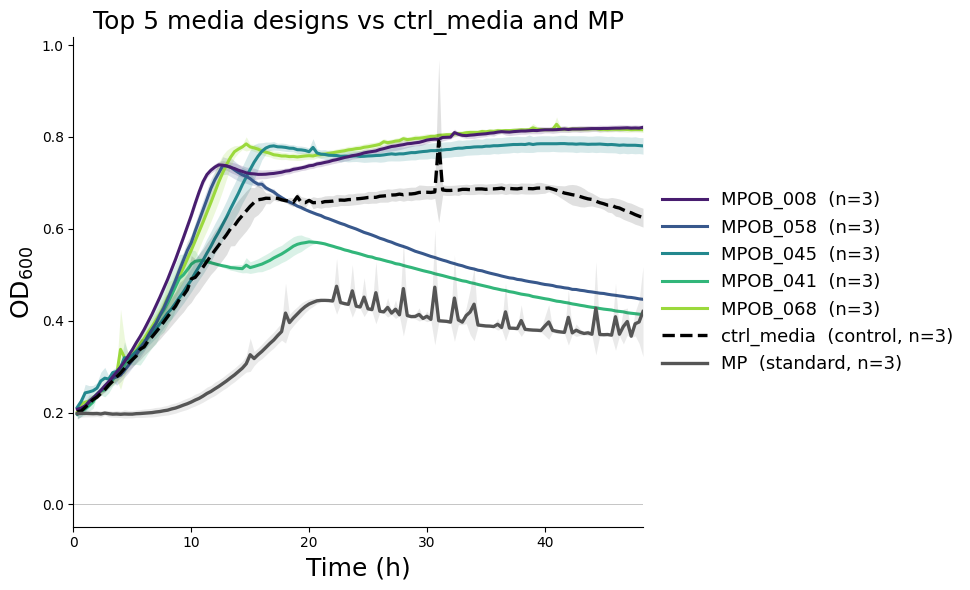

In [42]:
# --- Omics: load local data + plot (self-contained; re-run after tweaks) ---
import datetime
import openpyxl

# Paths (data lives in this analysis folder)
OMICS_XLSX = HERE / 'data' / 'omics_growth' / '05222026_top5_media_dbtl1.xlsx'
OMICS_OUT = HERE / 'outputs' / 'conditions'
OMICS_OUT.mkdir(parents=True, exist_ok=True)

# Well map
OMICS_TOP5 = {
    'MPOB_008': ['B2', 'B3', 'B4'],
    'MPOB_058': ['B5', 'B6', 'B7'],
    'MPOB_045': ['C2', 'C3', 'C4'],
    'MPOB_041': ['C5', 'C6', 'C7'],
    'MPOB_068': ['D2', 'D3', 'D4'],
}
OMICS_CONTROLS = {
    'ctrl_media': ['D5', 'D6', 'D7'],
    'MP':          ['E2', 'E3', 'E4'],
}
OMICS_BLANK_WELLS = ['B1', 'C1', 'D1', 'E1', 'B8', 'C8', 'D8', 'E8']
OMICS_SUBTRACT_BLANK = False

# --- tweak style here ---
FIGSIZE = (9, 6)
FS_LABEL = 18
FS_TITLE = 18
FS_LEGEND = 13
FS_TICKS = 10
DPI = 300

CMAP_NAME = 'viridis'
CMAP_LO, CMAP_HI = 0.08, 0.85
CTRL_COLOR, CTRL_LS, CTRL_LW = 'black', '--', 2.4
MP_COLOR, MP_LS, MP_LW = '#555555', '-', 2.4
TOP_LW = 2.2
BAND_ALPHA_TOP = 0.18
BAND_ALPHA_CTRL = 0.12

SHOW_TOP5 = list(OMICS_TOP5.keys())          # e.g. ['MPOB_008', 'MPOB_068']
SHOW_CONTROLS = ['ctrl_media', 'MP']        # or just ['ctrl_media']
LEGEND_LOC = 'center left'   # outside axes; paired with bbox_to_anchor below


def _to_hours(v):
    if isinstance(v, datetime.timedelta):
        return v.total_seconds() / 3600.0
    if isinstance(v, datetime.time):
        return (v.hour * 3600 + v.minute * 60 + v.second) / 3600.0
    return np.nan


wb = openpyxl.load_workbook(OMICS_XLSX, data_only=True)
ws = wb['Sheet1']
header = [c.value for c in ws[1]]
col_of = {name: i for i, name in enumerate(header) if name}
rows = list(ws.iter_rows(min_row=2, values_only=True))
t = np.array([_to_hours(r[0]) for r in rows])
data = {}
for name, idx in col_of.items():
    if name in ('Time', 'T° abs600:600'):
        continue
    data[name] = np.array([r[idx] for r in rows], dtype=float)
omics_df = pd.DataFrame(data, index=t)
omics_df.index.name = 'time_h'
print(f'loaded {len(omics_df)} timepoints, {omics_df.shape[1]} wells from {OMICS_XLSX.name}')

blank = (omics_df[OMICS_BLANK_WELLS].mean(axis=1).values
         if OMICS_SUBTRACT_BLANK else None)


def _mean_std(wells):
    sub = omics_df[wells].values
    if blank is not None:
        sub = sub - blank[:, None]
    return sub.mean(axis=1), sub.std(axis=1, ddof=1), sub.shape[1]


fig, ax = plt.subplots(figsize=FIGSIZE)
cmap = plt.colormaps[CMAP_NAME](np.linspace(CMAP_LO, CMAP_HI, len(SHOW_TOP5)))

for i, name in enumerate(SHOW_TOP5):
    mean, std, n = _mean_std(OMICS_TOP5[name])
    ax.plot(t, mean, color=cmap[i], lw=TOP_LW,
            label=f'{name}  (n={n})', zorder=5 - 0.01 * i)
    ax.fill_between(t, mean - std, mean + std,
                    color=cmap[i], alpha=BAND_ALPHA_TOP, lw=0)

if 'ctrl_media' in SHOW_CONTROLS:
    mean, std, n = _mean_std(OMICS_CONTROLS['ctrl_media'])
    ax.plot(t, mean, color=CTRL_COLOR, lw=CTRL_LW, ls=CTRL_LS,
            label=f'ctrl_media  (control, n={n})', zorder=10)
    ax.fill_between(t, mean - std, mean + std,
                    color=CTRL_COLOR, alpha=BAND_ALPHA_CTRL, lw=0, zorder=9)

if 'MP' in SHOW_CONTROLS:
    mean, std, n = _mean_std(OMICS_CONTROLS['MP'])
    ax.plot(t, mean, color=MP_COLOR, lw=MP_LW, ls=MP_LS,
            label=f'MP  (standard, n={n})', zorder=10)
    ax.fill_between(t, mean - std, mean + std,
                    color=MP_COLOR, alpha=BAND_ALPHA_CTRL, lw=0, zorder=9)

ax.set_xlabel('Time (h)', fontsize=FS_LABEL)
ax.set_ylabel('OD$_{600}$' + (' (blank-subtracted)' if OMICS_SUBTRACT_BLANK else ''),
              fontsize=FS_LABEL)
ax.set_title('Top 5 media designs vs ctrl_media and MP', fontsize=FS_TITLE)
ax.legend(loc=LEGEND_LOC, bbox_to_anchor=(1.02, 0.5),
          fontsize=FS_LEGEND, frameon=False, handlelength=2.5,
          borderaxespad=0)
ax.axhline(0, color='black', lw=0.4, alpha=0.4)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.tick_params(labelsize=FS_TICKS)
ax.set_xlim(0, float(np.nanmax(t)))
fig.tight_layout()
fig.subplots_adjust(right=0.72)  # room for outside legend

out_png = OMICS_OUT / 'growth_curves_top5_vs_controls_nb.png'
out_pdf = OMICS_OUT / 'growth_curves_top5_vs_controls_nb.pdf'
fig.savefig(out_png, dpi=DPI, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print(f'wrote {out_png}')
print(f'wrote {out_pdf}')
plt.show()
